<a href="https://colab.research.google.com/github/danadorn/lab6-clustering-student/blob/master/lab6_pca_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 1: Principal Component Analysis (PCA)
## Dimensionality Reduction Techniques

**Objective:** Understand and implement PCA for dimensionality reduction and data visualization.

**Learning Outcomes:**
- Understand the concept of dimensionality reduction
- Apply PCA to reduce high-dimensional data
- Visualize data before and after dimensionality reduction
- Interpret explained variance and choose optimal components


## Part 1: Setup and Data Loading

First, let's import the necessary libraries and load our dataset.

In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Set random seed for reproducibility
np.random.seed(42)

# Configure plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


### Load the Iris Dataset

The Iris dataset contains 150 samples of iris flowers with 4 features each.

In [ ]:
# TODO: Load the iris dataset
# Hint: Use load_iris() function
iris = None  # Replace None with the correct code

# Create DataFrame for easier manipulation
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Display basic information
print(f"Dataset shape: {X.shape}")
print(f"Features: {feature_names}")
print(f"Target classes: {target_names}")

# Create a DataFrame for better visualization
df = pd.DataFrame(X, columns=feature_names)
df['species'] = [target_names[i] for i in y]
df.head()

## Part 2: Data Exploration and Preprocessing

Before applying PCA, it's important to understand our data and standardize it.

In [ ]:
# Visualize the data distribution
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, feature in enumerate(feature_names):
    for species in range(3):
        axes[idx].hist(X[y==species, idx], alpha=0.5, label=target_names[species], bins=20)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()

plt.tight_layout()
plt.show()

### Standardize the Data

**Question:** Why is standardization important before PCA?

**Your Answer:**
_[Write your answer here]_

In [ ]:
# TODO: Initialize and fit the StandardScaler
# Hint: Create a StandardScaler object and use fit_transform()
scaler = None  # Replace None with StandardScaler()
X_scaled = None  # Replace None with the scaled data

print(f"Original data - Mean: {X.mean(axis=0)}")
print(f"Original data - Std: {X.std(axis=0)}")
print(f"\nScaled data - Mean: {X_scaled.mean(axis=0)}")
print(f"Scaled data - Std: {X_scaled.std(axis=0)}")

## Part 3: Applying PCA

Now let's apply PCA to reduce the dimensionality from 4D to 2D.

In [ ]:
# TODO: Apply PCA with 2 components
# Hint: Initialize PCA with n_components=2 and use fit_transform()
pca = None  # Replace None with PCA initialization
X_pca = None  # Replace None with transformed data

print(f"Original shape: {X_scaled.shape}")
print(f"Reduced shape: {X_pca.shape}")
print(f"\nExplained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

### Visualize PCA Results

Let's visualize how PCA has transformed our 4D data into 2D.

In [ ]:
# Create a scatter plot of the PCA results
plt.figure(figsize=(10, 8))

colors = ['red', 'green', 'blue']
for i, (color, target_name) in enumerate(zip(colors, target_names)):
    plt.scatter(X_pca[y==i, 0], X_pca[y==i, 1],
                color=color, label=target_name, alpha=0.7, s=100)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('PCA of Iris Dataset')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

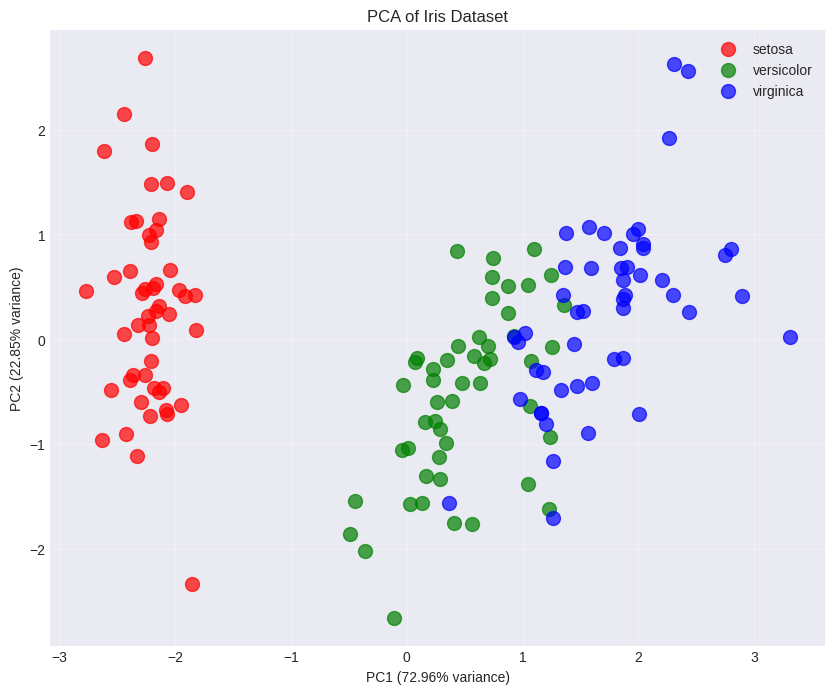

## Part 4: Choosing the Number of Components

How do we decide how many components to keep?

In [ ]:
# TODO: Apply PCA with all components to analyze variance
# Hint: Don't specify n_components or set it to None
pca_full = None  # Replace None with PCA initialization
X_pca_full = None  # Replace None with fit_transform

# Calculate cumulative variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Plot explained variance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Individual variance
ax1.bar(range(1, len(pca_full.explained_variance_ratio_)+1),
        pca_full.explained_variance_ratio_)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance Explained')
ax1.set_title('Variance Explained by Each Component')

# Cumulative variance
ax2.plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'bo-')
ax2.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance Explained')
ax2.set_title('Cumulative Variance Explained')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Variance explained by each component:")
for i, var in enumerate(pca_full.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.2%}")

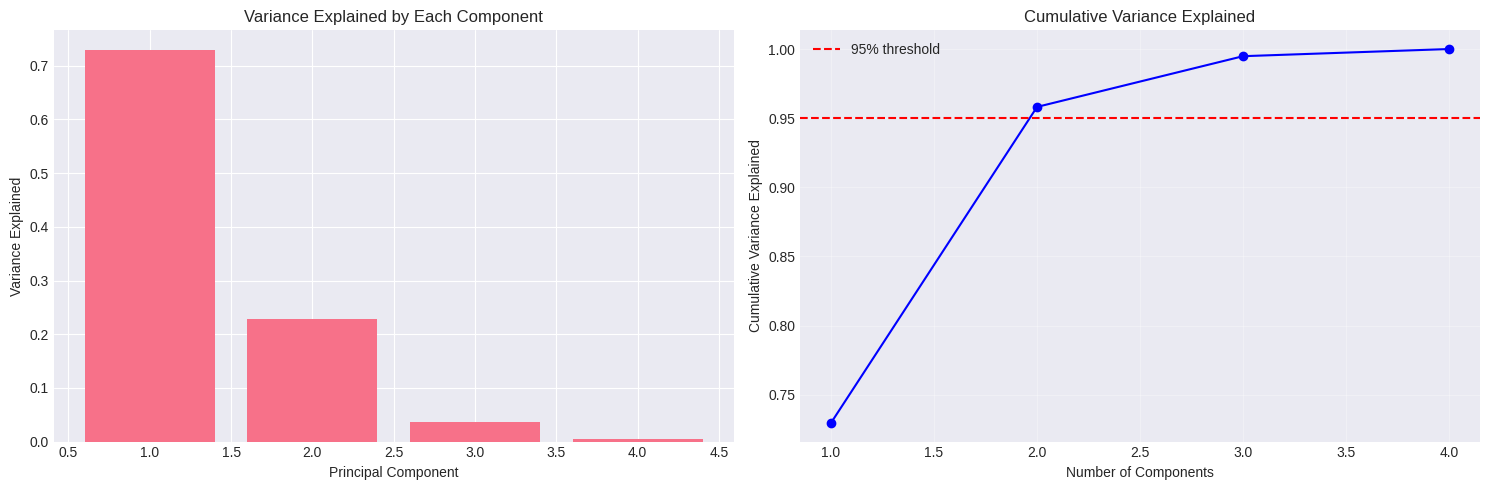

**Question:** Based on the plots above, how many components would you choose to retain 95% of the variance?

**Your Answer:**
_[Write your answer here]_

## Part 5: Feature Importance in Principal Components

Let's examine which original features contribute most to each principal component.

In [ ]:
# Create a DataFrame of component loadings
loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f'PC{i+1}' for i in range(len(pca_full.components_))],
    index=feature_names
)

print("Component Loadings (Feature Contributions):")
print(loadings)

# Visualize loadings as a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0,
            fmt='.3f', cbar_kws={'label': 'Loading Value'})
plt.title('PCA Component Loadings\n(How much each feature contributes to each PC)')
plt.tight_layout()
plt.show()

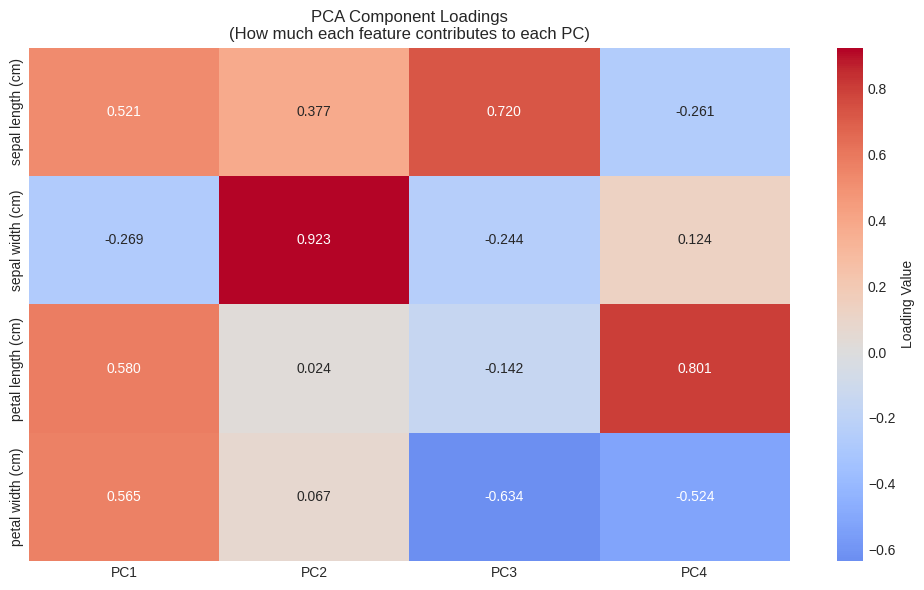

## Part 6: Real-World Application - Breast Cancer Dataset

Now let's apply PCA to a more complex dataset with 30 features.

In [ ]:
# Load breast cancer dataset
cancer = load_breast_cancer()
X_cancer = cancer.data
y_cancer = cancer.target

print(f"Dataset shape: {X_cancer.shape}")
print(f"Number of features: {X_cancer.shape[1]}")
print(f"Classes: {cancer.target_names}")

In [ ]:
# TODO: Standardize and apply PCA to breast cancer data
# Step 1: Standardize the data
scaler_cancer = None  # Initialize StandardScaler
X_cancer_scaled = None  # Scale the data

# Step 2: Apply PCA with 2 components
pca_cancer = None  # Initialize PCA with 2 components
X_cancer_pca = None  # Transform the data

print(f"Variance explained by 2 components: {pca_cancer.explained_variance_ratio_.sum():.2%}")

In [ ]:
# Visualize the results
plt.figure(figsize=(10, 8))

colors = ['red', 'blue']
for i, (color, target_name) in enumerate(zip(colors, cancer.target_names)):
    plt.scatter(X_cancer_pca[y_cancer==i, 0], X_cancer_pca[y_cancer==i, 1],
                color=color, label=target_name, alpha=0.6, s=50)

plt.xlabel(f'PC1 ({pca_cancer.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca_cancer.explained_variance_ratio_[1]:.2%} variance)')
plt.title('PCA of Breast Cancer Dataset (30D → 2D)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

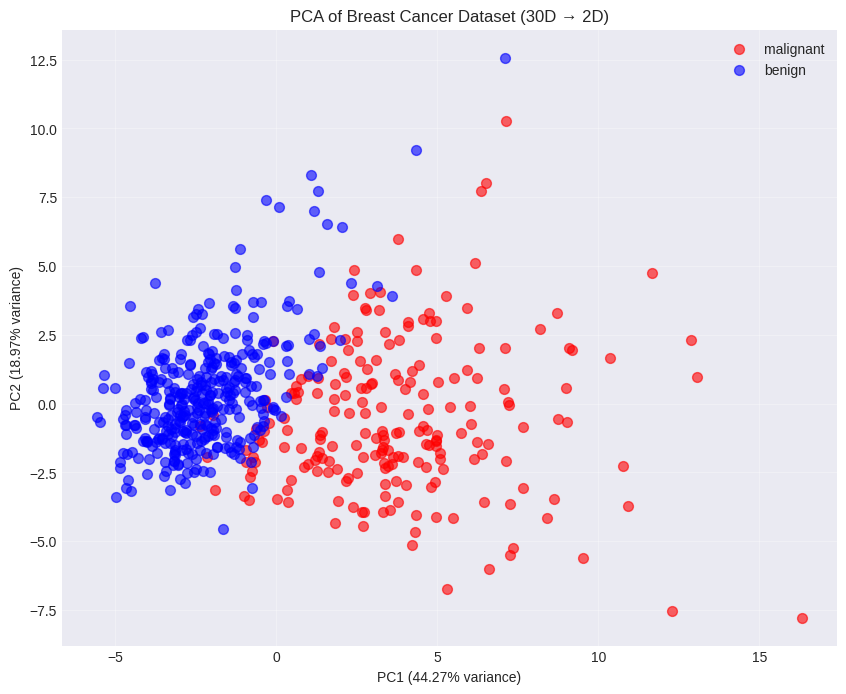

## Part 7: Reflection Questions

Answer the following questions based on your understanding:

1. **What is the main purpose of PCA?**
   
   _[Your answer here]_

2. **When would you use PCA in a machine learning project?**
   
   _[Your answer here]_

3. **What are the advantages and disadvantages of dimensionality reduction?**
   
   _[Your answer here]_

4. **How does the number of samples affect PCA performance?**
   
   _[Your answer here]_

## Bonus Challenge (Optional)

Try applying PCA to a custom dataset or experiment with different numbers of components!

In [ ]:
# Your code here
